In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

import torch
import numpy as np
import random
import os
from torch.utils.data import DataLoader
def set_seed(seed):
    random.seed(seed)
    np.random.default_rng(seed)
    torch.manual_seed(seed)

    # Ensure that CUDA operations are deterministic if using GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True
        # # slower but more reproducibility
        # torch.backends.cudnn.benchmark = False
set_seed(42)

In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import ClipTypes, OdometerTicks, OdometerTickRange, ViewDistance
from ilipy.sensors import ArmAngleLookup

from tqdm import tqdm
from typing import Dict

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.dataset_multi_channel_v1_1 import NumpyImageFolder

In [4]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [5]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

In [6]:
model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_v1_3_16.pth")
transform = transforms.Compose(
    [
        transforms.Lambda(resize_to_224), # should output (C, H, W)
        transforms.Lambda(lambda x: torch.from_numpy(x).float()),
        transforms.Normalize(
            mean=weights.transforms().mean, std=weights.transforms().std
        ),
    ]
)

In [7]:
val_dir = "./data/fhr4/final_data_v1.2/validation"
val_ds2 = NumpyImageFolder(root_dir=val_dir, transform=transform, debug=True)
val_loader2 = DataLoader(val_ds2, batch_size=2, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

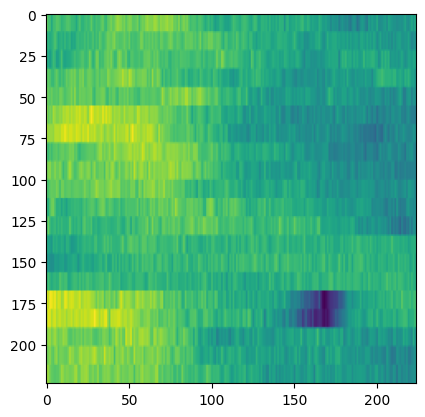

fhr4_d0115892170.npy
tensor([3.3484e-08, 1.0811e-07, 2.0505e-08, 6.2739e-07, 3.2846e-06, 5.3278e-07,
        2.7712e-08, 3.0745e-06, 3.9547e-08, 2.6369e-07, 7.6502e-06, 2.3563e-07,
        4.7467e-06, 1.9664e-07, 4.3076e-05, 9.9980e-01, 9.9724e-01, 2.3855e-05,
        2.6054e-06, 1.5047e-06], device='cuda:0')
15
tensor([3.3484e-08, 1.0811e-07, 2.0505e-08, 6.2739e-07, 3.2846e-06, 5.3278e-07,
        2.7712e-08, 3.0745e-06, 3.9547e-08, 2.6369e-07, 7.6502e-06, 2.3563e-07,
        4.7467e-06, 1.9664e-07, 4.3076e-05, 9.9980e-01, 9.9724e-01, 2.3855e-05,
        2.6054e-06, 1.5047e-06], device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True, False, False, False],
       device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True, False, False, False],
       device='cuda:0')


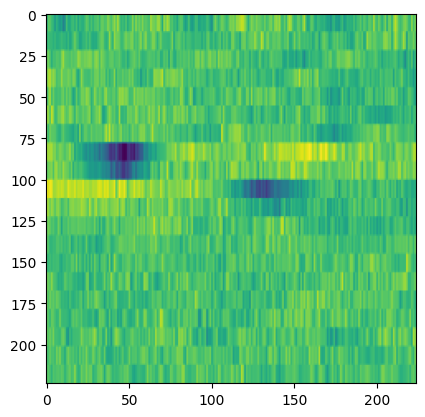

fhr4_d0119253330.npy
tensor([4.5813e-05, 1.5335e-06, 1.0912e-06, 2.5004e-06, 7.0410e-06, 1.6461e-06,
        2.3925e-04, 9.6609e-01, 9.7702e-01, 9.9486e-01, 2.6607e-03, 7.4007e-09,
        1.7079e-07, 8.0291e-06, 5.6347e-09, 2.4961e-06, 2.7211e-07, 2.0740e-06,
        4.3866e-06, 7.9250e-07], device='cuda:0')
9
tensor([4.5813e-05, 1.5335e-06, 1.0912e-06, 2.5004e-06, 7.0410e-06, 1.6461e-06,
        2.3925e-04, 9.6609e-01, 9.7702e-01, 9.9486e-01, 2.6607e-03, 7.4007e-09,
        1.7079e-07, 8.0291e-06, 5.6347e-09, 2.4961e-06, 2.7211e-07, 2.0740e-06,
        4.3866e-06, 7.9250e-07], device='cuda:0')
tensor([False, False, False, False, False, False, False,  True,  True,  True,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')
tensor([False, False, False, False, False, False, False,  True,  True,  True,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')


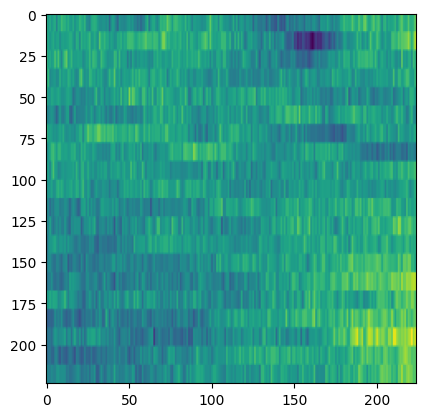

fhr4_d0124551540.npy
tensor([2.7157e-02, 8.1767e-01, 1.8031e-05, 7.4391e-08, 6.7808e-08, 1.2747e-07,
        5.3052e-07, 1.1302e-09, 3.6529e-10, 9.4651e-07, 1.6525e-07, 3.3553e-08,
        5.0340e-07, 7.6066e-08, 1.6493e-06, 6.9414e-08, 1.3855e-07, 3.3414e-07,
        1.0158e-06, 7.2083e-06], device='cuda:0')
1
tensor([2.7157e-02, 8.1767e-01, 1.8031e-05, 7.4391e-08, 6.7808e-08, 1.2747e-07,
        5.3052e-07, 1.1302e-09, 3.6529e-10, 9.4651e-07, 1.6525e-07, 3.3553e-08,
        5.0340e-07, 7.6066e-08, 1.6493e-06, 6.9414e-08, 1.3855e-07, 3.3414e-07,
        1.0158e-06, 7.2083e-06], device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')
tensor([False,  True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')


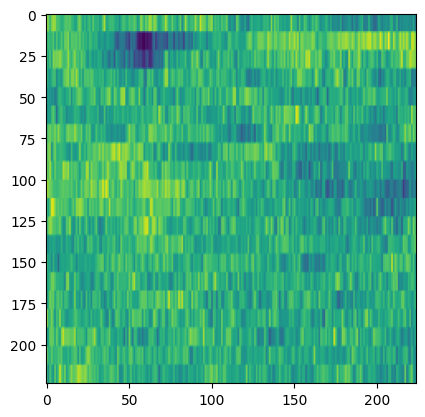

fhr4_d0119142370.npy
tensor([1.2793e-03, 9.9899e-01, 9.7113e-01, 1.8931e-05, 2.9401e-06, 3.2852e-06,
        3.9095e-06, 2.7927e-07, 2.2760e-09, 1.2158e-07, 1.9586e-06, 8.8588e-08,
        7.4230e-07, 7.3702e-07, 3.7163e-07, 1.3243e-07, 4.2131e-07, 5.5452e-07,
        1.6554e-06, 1.0255e-06], device='cuda:0')
1
tensor([1.2793e-03, 9.9899e-01, 9.7113e-01, 1.8931e-05, 2.9401e-06, 3.2852e-06,
        3.9095e-06, 2.7927e-07, 2.2760e-09, 1.2158e-07, 1.9586e-06, 8.8588e-08,
        7.4230e-07, 7.3702e-07, 3.7163e-07, 1.3243e-07, 4.2131e-07, 5.5452e-07,
        1.6554e-06, 1.0255e-06], device='cuda:0')
tensor([False,  True,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')
tensor([False,  True,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')


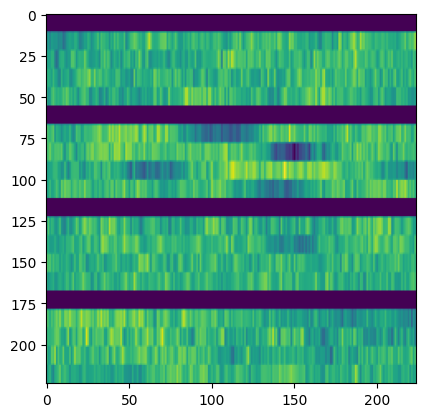

fhr4_d0165940680.npy
tensor([6.9195e-10, 1.5374e-09, 4.0826e-11, 1.2314e-10, 2.6757e-11, 2.9718e-10,
        1.1016e-08, 1.3018e-09, 2.0831e-09, 1.5050e-07, 8.3613e-10, 2.3883e-12,
        1.6709e-10, 1.9843e-10, 1.2085e-09, 2.3045e-08, 1.6488e-10, 9.6337e-11,
        8.5569e-10, 2.1200e-10], device='cuda:0')
0
tensor([6.9195e-10, 1.5374e-09, 4.0826e-11, 1.2314e-10, 2.6757e-11, 2.9718e-10,
        1.1016e-08, 1.3018e-09, 2.0831e-09, 1.5050e-07, 8.3613e-10, 2.3883e-12,
        1.6709e-10, 1.9843e-10, 1.2085e-09, 2.3045e-08, 1.6488e-10, 9.6337e-11,
        8.5569e-10, 2.1200e-10], device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')


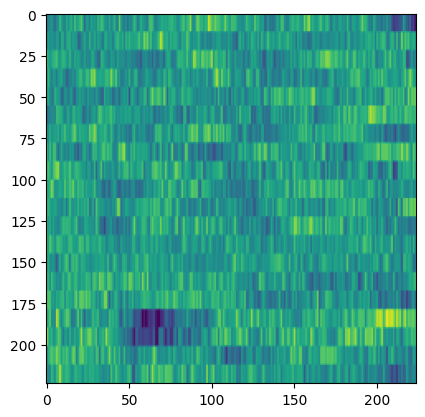

fhr4_d0130736360.npy
tensor([1.1968e-07, 1.6821e-07, 1.4790e-07, 3.2196e-08, 6.0648e-07, 6.4574e-08,
        7.8605e-10, 2.6844e-08, 6.4159e-08, 8.3427e-08, 2.2404e-06, 2.5827e-07,
        3.4576e-07, 9.1152e-07, 6.8774e-07, 8.7236e-05, 8.1243e-01, 2.1181e-02,
        1.8011e-06, 3.8818e-07], device='cuda:0')
16
tensor([1.1968e-07, 1.6821e-07, 1.4790e-07, 3.2196e-08, 6.0648e-07, 6.4574e-08,
        7.8605e-10, 2.6844e-08, 6.4159e-08, 8.3427e-08, 2.2404e-06, 2.5827e-07,
        3.4576e-07, 9.1152e-07, 6.8774e-07, 8.7236e-05, 8.1243e-01, 2.1181e-02,
        1.8011e-06, 3.8818e-07], device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False],
       device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False, False],
       device='cuda:0')


In [8]:
model.eval()
model.to(device)
all_preds = []
all_labels = []
pred_list = []
vd_list = []
total_mislabeled = 0
with torch.inference_mode():
    for batch_idx, (inputs, labels, names) in enumerate(val_loader2):
        # labels expected shape [B] with 0/1
        
            inputs = inputs.to(device)
            labels = labels.float().to(device)
            labels=torch.ones(inputs.size(0)).to(device)

            raw_outputs = model(inputs)
            for i in range(inputs.size(0)):

                if "fhr4" in names[i]:
                    #plot inputs
                    plt.imshow(inputs[i,2,:].cpu().numpy())
                    plt.show()
                    print(names[i])
                    all_val_probs = torch.sigmoid(raw_outputs[i])
                    print(all_val_probs)
                    if torch.any(all_val_probs >= 0.5):
                        preds = raw_outputs.argmax(axis=1)
                    else:
                        preds = torch.zeros_like(raw_outputs.argmax(axis=1))
                        total_mislabeled += 1
                    print(preds[i].item())
                    print(all_val_probs)
                    print(all_val_probs >= 0.9)
                    print(all_val_probs >= 0.5)
                    pred_list.append(preds[i].item())
                    vd_list.append(int(names[i].split("_")[-1].replace(".npy","")[2:]))


In [9]:
total_mislabeled

1

Threshold 0.4: 1/12 mislabeled (8.3%)
Threshold 0.5: 1/12 mislabeled (8.3%)
Threshold 0.6: 1/12 mislabeled (8.3%)
Threshold 0.7: 1/12 mislabeled (8.3%)
Threshold 0.8: 1/12 mislabeled (8.3%)
Threshold 0.9: 3/12 mislabeled (25.0%)


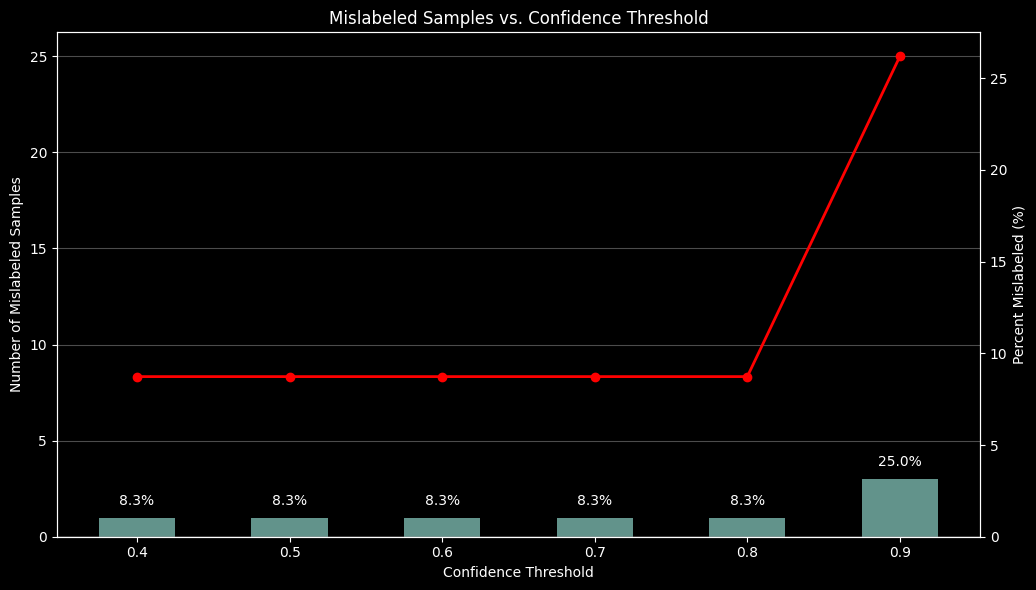

In [10]:
# Evaluate model across different thresholds
model.eval()
model.to(device)

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for threshold in thresholds:
    total_mislabeled = 0
    total_samples = 0
    
    with torch.inference_mode():
        for batch_idx, (inputs, labels, names) in enumerate(val_loader2):
            inputs = inputs.to(device)
            # Assuming all samples are positive (have dents)
            labels = torch.ones(inputs.size(0)).to(device)
            total_samples += inputs.size(0)
            
            # Forward pass
            raw_outputs = model(inputs)
            all_probs = torch.sigmoid(raw_outputs)
            
            # Count samples where no class exceeds the threshold (mislabeled)
            for i in range(inputs.size(0)):
                if not torch.any(all_probs[i] >= threshold):
                    total_mislabeled += 1
    
    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'mislabeled': total_mislabeled,
        'total': total_samples,
        'mislabeled_percent': (total_mislabeled / total_samples) * 100
    })
    print(f"Threshold {threshold:.1f}: {total_mislabeled}/{total_samples} mislabeled ({total_mislabeled/total_samples:.1%})")

# Plotting
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
mislabeled_counts = [r['mislabeled'] for r in results]
mislabeled_percent = [r['mislabeled_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, mislabeled_counts, width=0.05, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, mislabeled_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.1f}%', ha='center', va='bottom')

# Add a line showing percentage
plt.plot(thresholds, mislabeled_percent, 'r-o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Mislabeled Samples')
plt.title('Mislabeled Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Mislabeled (%)')
ax2.plot(thresholds, mislabeled_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(mislabeled_percent) * 1.1)

plt.show()

## upload bookmarks


In [11]:
from __future__ import annotations

from ilipy import Session
from ilipy.channeldata import ChannelDataReader, ImageProfile
from ilipy.features import Bookmarks

from ilipyutils.ml_features.base import (
    AnomalyStatus,
    get_ml_models_info_list,
)
from ilipyutils.ml_features.insert import FeatureInsert, GeometryCubeParameters
from ilipy import ClipTypes, TrackIndex, ViewDistance

session = Session(environment="research")
bookmarks_interface = Bookmarks(connector=session.database_connector)

feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)

PySettings.cpp(46): ilipy: Build 0.17.5.11628 cbc18e3397 release-ili-0.17 'Tue Sep 16 22:43:55 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(153): WebSoc

In [12]:
inspection_id = "09JBC62FLJZ"
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v1"
)
model_info

MLModelInfo(model_name='Dent-Detection-v1', model_id=7, model_score_bound=[0, None], anomaly_type_name='DentPlain')

In [13]:
session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8083, Concurrent Connections: 1
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8083, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8083) : 200, 2ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8083) : 200, 130ms
PySession.cpp(84): Initialized with inspection: 09JBC62FLJZ
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8083, Concurrent Connections: 3
BasicThreadPool.cpp(20): Initializing SharedThreadPool with 8 threads
DistanceC

In [14]:
session.set_active_inspection(inspection_id)
clips = session.get_clips_by_type(ClipTypes.ChannelData)

PySession.cpp(84): Initialized with inspection: 09JBC62FLJZ


In [15]:
pred_list, vd_list

([15, 9, 1, 1, 0, 16],
 [115892170, 119253330, 124551540, 119142370, 165940680, 130736360])

In [16]:
patch_length=0.3
for i, (vd, pred) in enumerate(zip(vd_list, pred_list)):

    profile = ImageProfile.ZeroAngle 
    track_num = pred_list[i]

    start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_num), ViewDistance(vd/1000-patch_length/2)).value
    end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_num), ViewDistance(vd/1000+patch_length/2)).value
    print(vd, pred, start_frame_odo_ticks, end_frame_odo_ticks)
    # anomaly_info = feature_insert.insert_ml_pred(
    # inspection_id=inspection_id,
    # tlbr_track_indices=(track_num, track_num),
    # tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
    # cube_params=None,
    # model_info=model_info,
    # anomaly_status=AnomalyStatus.REVIEW_DETECTION,
    # image_profile=profile,
    # ili_custom_data=None
    # )
	

115892170 15 1158957795 1158960797
119253330 9 1192570504 1192573505
124551540 1 1245544426 1245547425
119142370 1 1191452725 1191455724
165940680 0 1659434174 1659437174
130736360 16 1307401332 1307404332
